# California House Price Prediction 

**1.Import libraries**

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 


**2.Load the California Housing Dataset**

In [2]:
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()
df=pd.DataFrame(housing.data,columns=housing.feature_names)
df[housing.target_names[0]] = housing.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


**3.data check**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [5]:
df.duplicated().sum()

0

**observation:**
- The dataset contains 20640 rows and 9 numerical columns.No categorical variables are present.
- The dataset does not contain missing values, so no imputation is required.
- No duplicate records were found in the dataset.
    

**4.Numerical analysis**

In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


**observations:**
- The dataset contains 20640 records with no missing values.
- The average median income is around 3.87, and the median house value ranges from 0.15 to 5.
- Some features like Population and AveRooms show very high maximum values, indicating possible outliers.

**5.correlation**

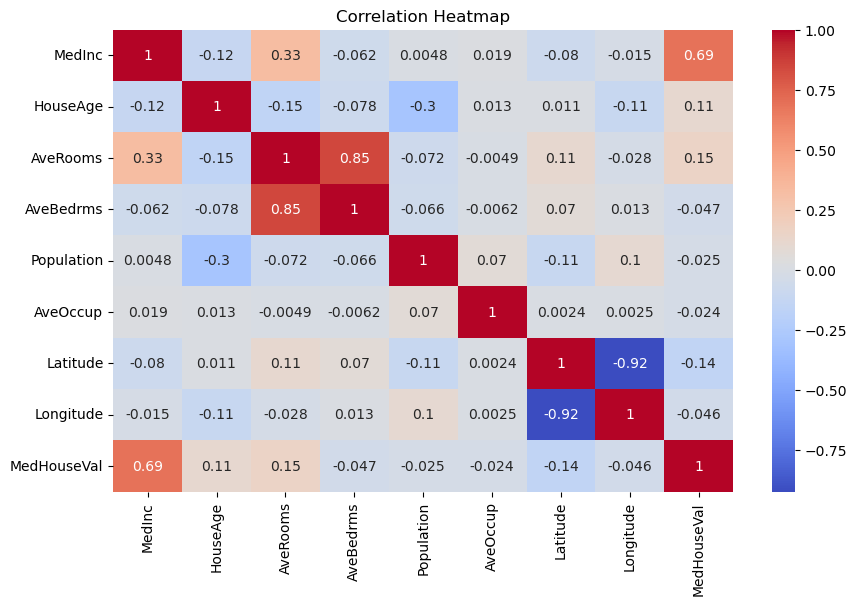

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**observation:**
- The correlation analysis shows that MedInc (Median Income) has the strongest positive correlation (0.69) with MedHouseVal, indicating that higher income areas tend to have higher house prices. Most other features show weak correlation with the target variable.

**6.outlier detection**

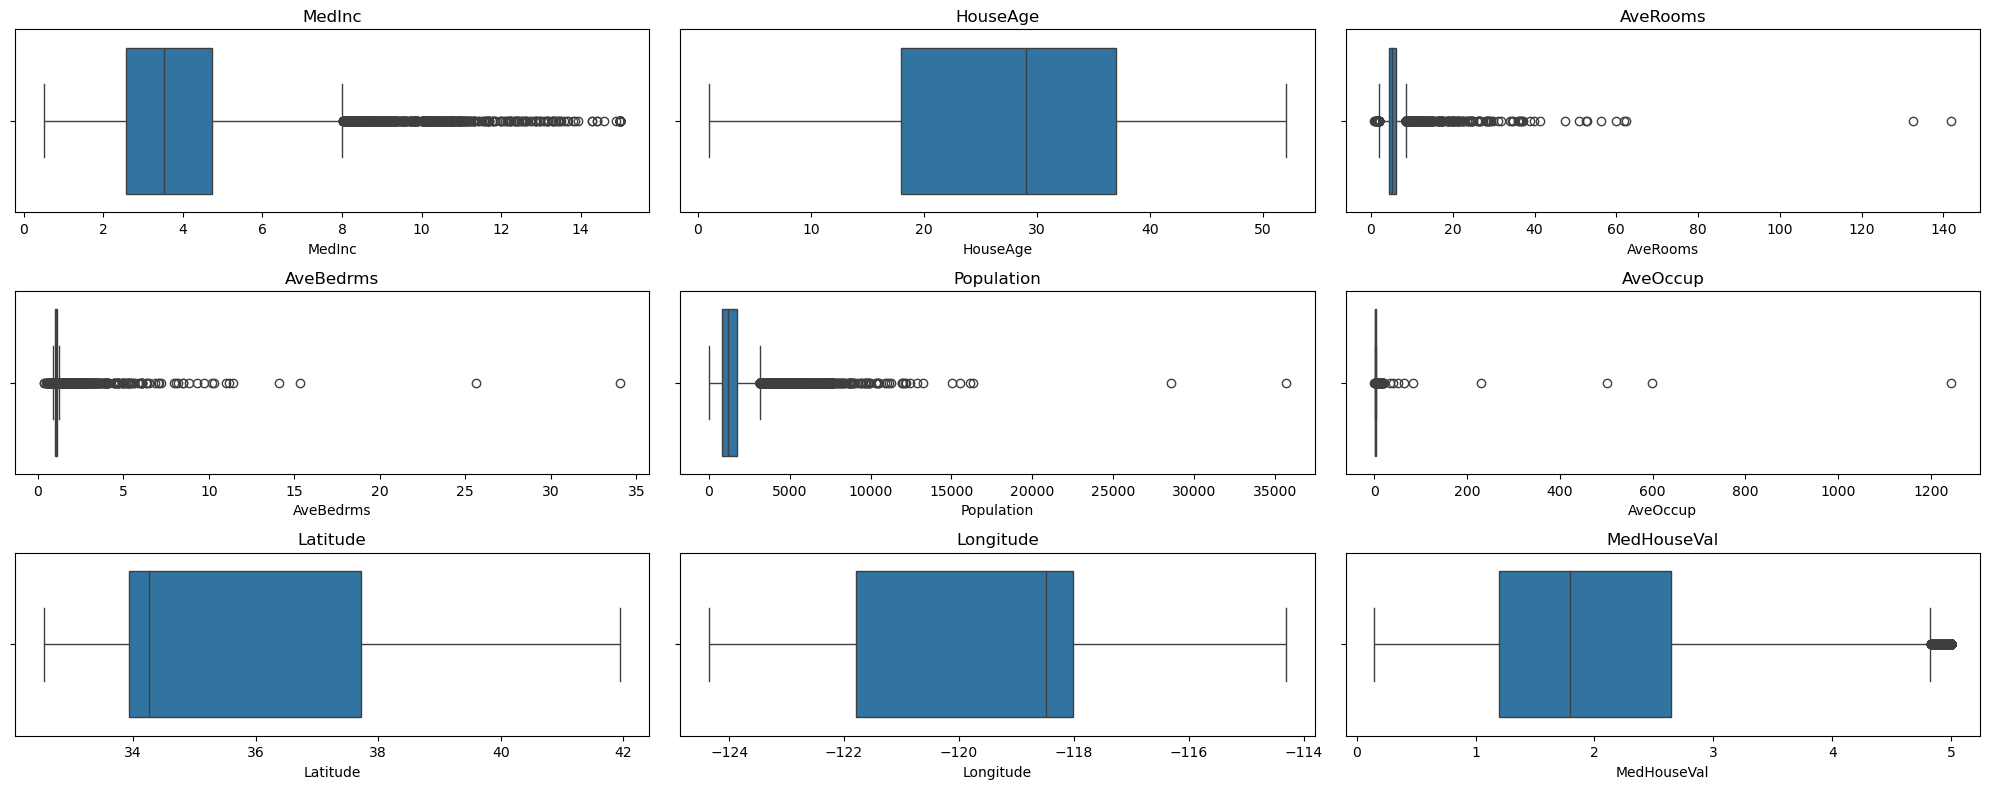

In [9]:
num = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(20,8))

for i, col in enumerate(num):
    
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [10]:
# outlier handling 
outlier_cols = ["MedInc","AveRooms","AveBedrms","Population","AveOccup"]

for col in outlier_cols:
    
    q1 = np.percentile(df[col],25)
    q3 = np.percentile(df[col],75)

    IQR = q3 - q1

    lb = q1 - 1.5 * IQR
    ub = q3 + 1.5 * IQR

    df[col] = df[col].clip(lb, ub)

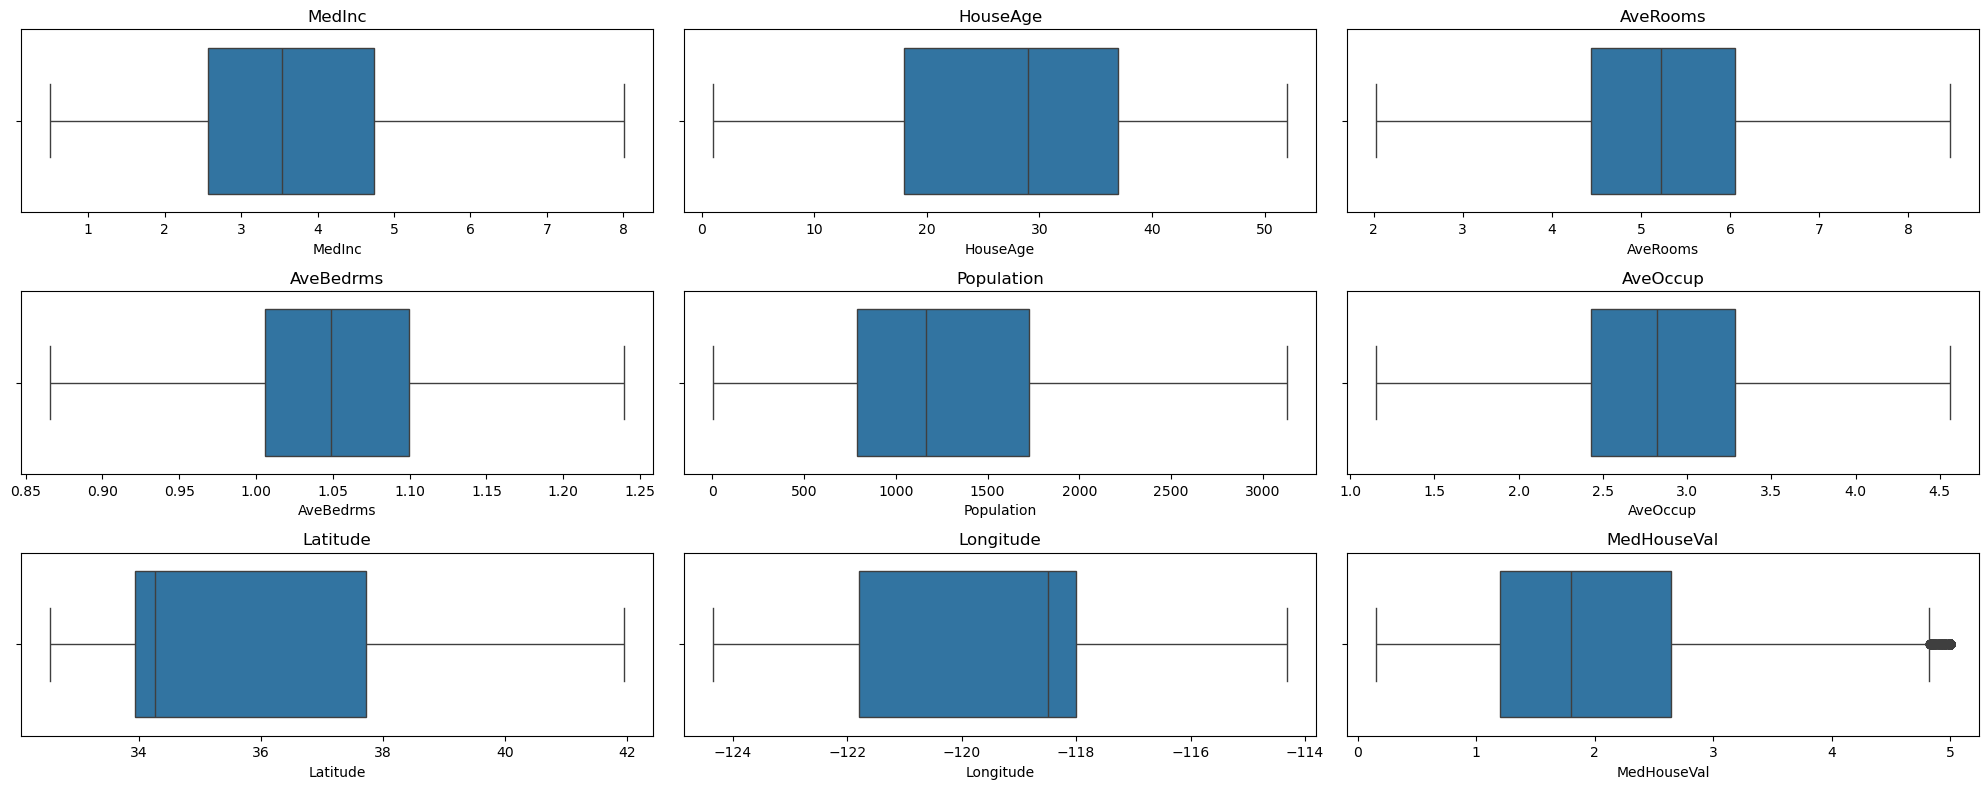

In [11]:
plt.figure(figsize=(20,8))

for i, col in enumerate(num):
    
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**7.standardization**

In [12]:
x=df.drop('MedHouseVal',axis=1)
y=df['MedHouseVal']


In [13]:
from sklearn.preprocessing import StandardScaler
SS=StandardScaler()
scaled_data=SS.fit_transform(x)

In [14]:
scaled_df=pd.DataFrame(scaled_data,columns=x.columns)
scaled_df['MedHouseVal']=y
scaled_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.541006,0.982143,1.347665,-0.424488,-1.325821,-0.497871,1.052548,-1.327835,4.526
1,2.541006,-0.607019,0.749027,-1.070004,1.389936,-1.142781,1.043185,-1.322844,3.585
2,2.085156,1.856182,2.394098,0.192534,-1.098528,-0.140910,1.038503,-1.332827,3.521
3,1.111288,1.856182,0.411358,0.187723,-1.017539,-0.508882,1.038503,-1.337818,3.413
4,0.027262,1.856182,0.784108,0.287439,-1.008395,-1.039145,1.038503,-1.337818,3.422
...,...,...,...,...,...,...,...,...,...
20635,-1.351765,-0.289187,-0.208070,0.936973,-0.642637,-0.490563,1.801647,-0.758826,0.781
20636,-0.750601,-0.845393,0.649438,2.259147,-1.281408,0.322894,1.806329,-0.818722,0.771
20637,-1.267488,-0.924851,-0.079603,0.772378,-0.431019,-0.830546,1.778237,-0.823713,0.923
20638,-1.166620,-0.845393,0.019880,1.416631,-0.778490,-1.123439,1.778237,-0.873626,0.847


**8. feature selection : VIF**

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor # package from statistics

x=scaled_df.drop('MedHouseVal',axis=1)
vif_list=[]
for i in range(len(x.columns)):
    vif_list.append(variance_inflation_factor(x.values,i))

vif_data=pd.DataFrame(vif_list,index=x.columns,columns=['VIF'])
vif_data

,VIF
MedInc,3.105420
HouseAge,1.303025
AveRooms,2.928213
AveBedrms,1.397706
Population,1.239721
AveOccup,1.141245
Latitude,10.254853
Longitude,9.667894


In [16]:
scaled_df = scaled_df.drop('Longitude', axis=1)

x = scaled_df.drop('MedHouseVal', axis=1)

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

x = scaled_df.drop('MedHouseVal', axis=1)

vif_list = []

for i in range(len(x.columns)):
    vif_list.append(variance_inflation_factor(x.values, i))

vif_data = pd.DataFrame(vif_list, index=x.columns, columns=['VIF'])

vif_data

,VIF
MedInc,2.487709
HouseAge,1.209944
AveRooms,2.526923
AveBedrms,1.387432
Population,1.234104
AveOccup,1.141105
Latitude,1.126827


**observation:**
- After removing the Longitude feature due to high multicollinearity, the VIF values for all remaining variables are below 5, indicating that multicollinearity is no longer a concern.

**9.model development**

In [20]:
final_df=scaled_df

X = final_df.drop('MedHouseVal', axis=1)
y = final_df['MedHouseVal']

In [21]:
# train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1234)

In [22]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 7)
(4128, 7)
(16512,)
(4128,)


**10.model training**

**Linear Regression**

In [26]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**11.model prediction**

In [27]:
y_pred = model.predict(x_test)

In [28]:
df=x_test.copy()
df['y_actual']=y_test
df['y_prediction']=y_pred
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,y_actual,y_prediction
15712,-0.072278,1.856182,-0.366269,0.257240,-0.944387,-1.700020,1.010411,5.00000,2.909189
4119,1.056571,1.856182,0.661473,-0.199169,0.659725,0.103196,-0.698469,2.93900,3.469226
15725,0.044637,1.220517,-0.453780,-0.415409,-1.013620,-1.705606,1.005730,4.12500,2.773658
14616,-0.199328,-0.686477,-0.024464,-0.303008,0.633600,0.722889,-1.325839,1.57600,1.608865
13238,2.366282,-1.481058,2.176439,-0.475345,-0.151475,0.781030,-0.703151,3.04100,3.289377
...,...,...,...,...,...,...,...,...,...
13521,0.848320,-0.686477,0.694520,-1.183305,-1.037133,-0.016421,-0.651651,1.64300,2.368887
16913,2.541006,-0.289187,2.539941,-0.375160,0.222121,0.130849,0.898047,5.00001,3.723727
20069,-0.759711,0.108104,-0.175516,1.418163,-1.430324,-0.430452,1.113413,1.23200,1.546481
446,0.044637,1.856182,-0.736258,-1.086068,-1.242219,-1.457752,1.047866,1.82600,2.807741


**12. model evaluation**

In [29]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.5280135619598798
RMSE: 0.7266454169399816
R2 Score: 0.609692073285069


**observation:**
- The Linear Regression model achieved an R² score of 0.61, indicating that the model explains approximately 61% of the variability in house prices. The RMSE value of 0.73 suggests a moderate prediction error, showing that the model performs reasonably well on the test data.

**13. assumption check**

**residual vs fitted plot**

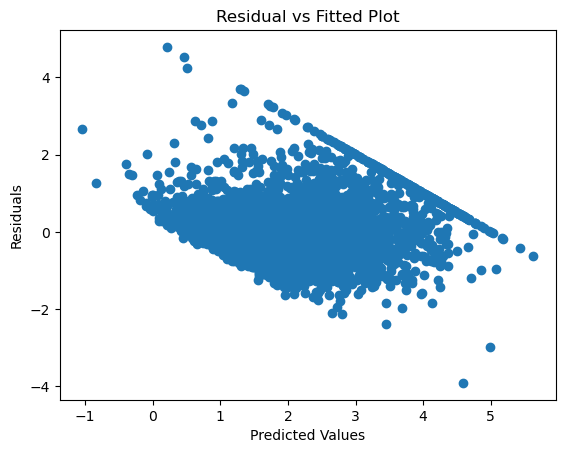

In [30]:
error = y_test - y_pred

plt.scatter(y_pred, error)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted Plot")
plt.show()

**observation:**
- The residual vs fitted plot shows that the residuals are approximately randomly distributed around zero without a clear pattern, indicating that the linear regression assumptions are reasonably satisfied.

**Actual vs Predicted plot**

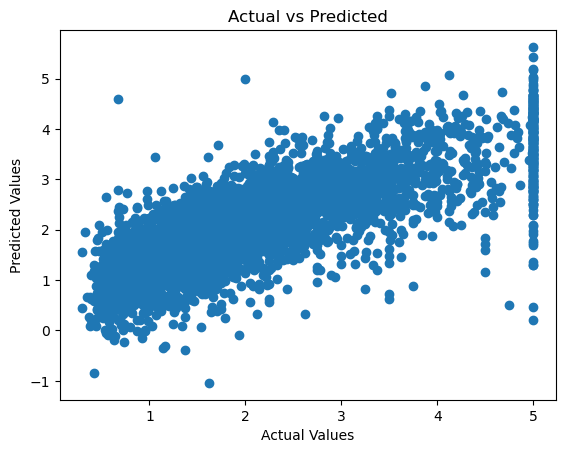

In [31]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

**observation:**
- The Actual vs Predicted plot shows a positive linear relationship between actual and predicted house prices. Most points follow the diagonal trend, indicating that the model predictions align reasonably well with the true values.

### model comparison

**14.Decision Tree Regressor**

In [32]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dt = DecisionTreeRegressor(random_state=42)

dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)


In [34]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.7632700472137354
RMSE: 0.8736532763137419
R2 Score: 0.43579034495663804


**15.Random Forest Regressor**

In [35]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)


In [36]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 0.3731890421549006
RMSE: 0.6108920053126417
R2 Score: 0.7241384467937627


### Model Comparison Table

In [37]:
import pandas as pd

models = ["Linear Regression", "Decision Tree", "Random Forest"]
scores = [
    r2_score(y_test, y_pred),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

comparison = pd.DataFrame({
    "Model": models,
    "R2 Score": scores
})

comparison

,Model,R2 Score
0,Linear Regression,0.609692
1,Decision Tree,0.435790
2,Random Forest,0.724138


**observation:**
- Three models were evaluated: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. Among them, the Random Forest model achieved the highest R² score of 0.72, indicating better predictive performance compared to the other models.

### 16.save the model 

In [38]:
import joblib

location = "california_house_price_model.joblib"
model_data = {
    "model": rf,      
    "columns": x_train.columns
}

joblib.dump(model_data, location)

['california_house_price_model.joblib']